In [1]:
!pip install networkx
!pip install python-louvain

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.optimize import curve_fit
from fonctions import constitution_df, construction_reseau, degree_distribution, plot_knn_logbins

# 1.Téléchargement des données et constitution des dataframes

In [3]:
path_data_check_in='/home/onyxia/work/Networks_projet/data/dataset_TSMC2014_TKY.txt'
path_data_users='/home/onyxia/work/Networks_projet/data/dataset_UbiComp2016_UserProfile_TKY.txt'

dfjoint_complet, dfjoint_micro, dfjoint_macro=constitution_df(path_data_check_in,path_data_users )


In [4]:
# Distribution du nombre de followers parmi les utilisateurs

dfjoint_complet['nb_twitter_followers'].quantile(
    [i/10 for i in range(1, 10)]
)

0.1     120.5
0.2     217.0
0.3     326.0
0.4     473.0
0.5     661.5
0.6     873.0
0.7    1084.0
0.8    1427.0
0.9    2360.0
Name: nb_twitter_followers, dtype: float64

# 2. Etude des réseaux

Nous commencerons par constituer un réseau complet tel que:
- les noeuds sont constitués d'établissements visités plus d'une fois
- ces établissements sont connectés par une arête si ils ont été visités par au moins un utilisateur commun

Puis nous focaliserons notre étude sur deux sous-réseaux:
- un réseau micro dont les liens ne sont constitués que par des utilisateurs ayant moins de 100 followers
- un réseau macro dont les liens sont constitués par des utilisateurs ayant plus de 2500 followers

Les seuils ont été déterminés en tenant compte de leur intreprétabilité la distribution de la variable *nb_twitter_followers*.

## 2.1 Constitution des réseaux


In [5]:
# Création des réseaux

G_complet= construction_reseau(dfjoint_complet)
G_micro= construction_reseau(dfjoint_micro)
G_macro= construction_reseau(dfjoint_macro)

In [ ]:
def afficher_infos_reseau(G, titre):
    print("\n" + "="*50)
    print(f"{titre}")
    print("="*50)
    
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    
    print(f"Nombre de lieux (nœuds) : {n_nodes}")
    print(f"Nombre de connexions (arêtes) : {n_edges}")
    print(f"Densité du réseau : {nx.density(G):.4f}")
    
    # Degré moyen
    deg_moyen = sum(dict(G.degree()).values()) / n_nodes
    print(f"Degré moyen : {deg_moyen:.2f}")
    
    # Connexité
    is_conn = nx.is_connected(G)
    print(f"Réseau entièrement connecté : {is_conn}")
    
    # Mesures seulement si connecté
    if is_conn:
        avg_path = nx.average_shortest_path_length(G)
        print(f"Distance moyenne : {avg_path:.2f}")
    else:
        print("Distance moyenne : non définie (réseau non connecté)")

afficher_infos_reseau(G_complet, 'Caractéristiques du réseau complet')
afficher_infos_reseau(G_macro, 'Caractéristiques du réseau macro')
afficher_infos_reseau(G_micro, 'Caractéristiques du réseau micro')


Caractéristiques du réseau complet
Nombre de lieux (nœuds) : 61858
Nombre de connexions (arêtes) : 10865915
Densité du réseau : 0.0057
Degré moyen : 351.32
Réseau entièrement connecté : True


In [ ]:
 
            avg_path_random = nx.average_shortest_path_length(G_random)
        else:
            largest_cc = max(nx.connected_components(G_random), key=len)
            avg_path_random = nx.average_shortest_path_length(G_random.subgraph(largest_cc))
     
    else:
        avg_path_length = None
        avg_path_random = None
        
    
    # Affichage
    print(f"Nombre de lieux (nœuds) : {n_nodes}")
    print(f"Nombre de connexions (arêtes) : {n_edges}")
    print(f"Densité du réseau : {density:.4f}")
    print(f"Degré moyen : {deg_mean:.2f}")
    
    if avg_path_length is not None:
        print(f"Distance moyenne : {avg_path_length:.2f}")
        print(f"Distance moyenne réseau aléatoire : {avg_path_random:.2f}")
    else:
        print("Distance moyenne, small-world ratio : non calculables (réseau non connecté)")


Le réseau d'établissements est très peu dense dans les trois cas, avec, par exemple, uniquement 0,64% des arêtes possibles dans le réseau complet effectivement présentes. Ce résultat était-il prévisible? Compte tenu du nombre important de lieux répertoriés ainsi que des contraintes géographiques et des caractéristiques des comportements humains (tendance à visiter les lieux proches ou recommandés). Nous pouvons faire l'hypothèse que le réseau est structuré en différents îlots, reliés entre eux par quelques hubs servant de ponts, liaisons qui expliquent que le réseau reste entièrement connecté.

## 2.2 Distribution des degrés

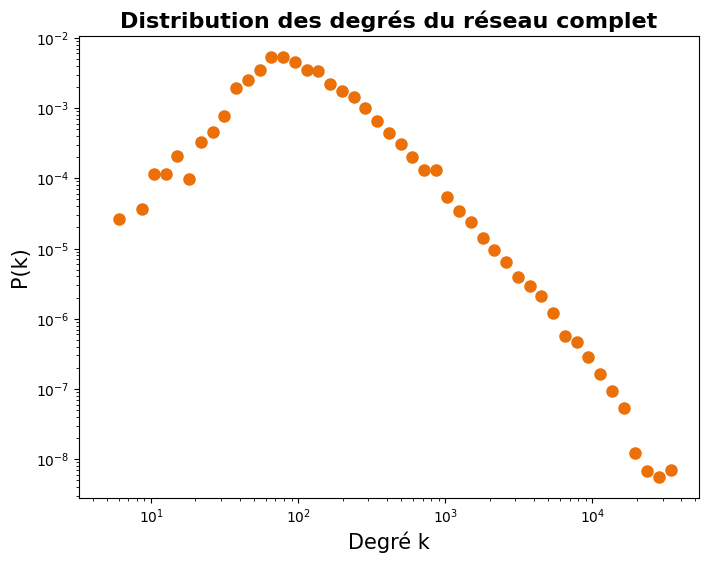

In [10]:
#  Réseau complet : distribution des degrés

degree_distribution(G_complet, titre='Distribution des degrés du réseau complet')

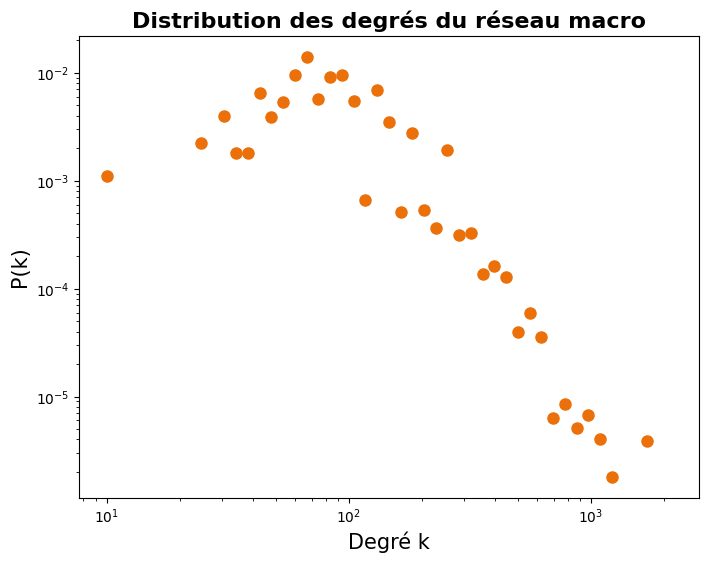

In [ ]:
#  Réseau macro : distribution des degrés

degree_distribution(G_macro, titre='Distribution des degrés du réseau macro')

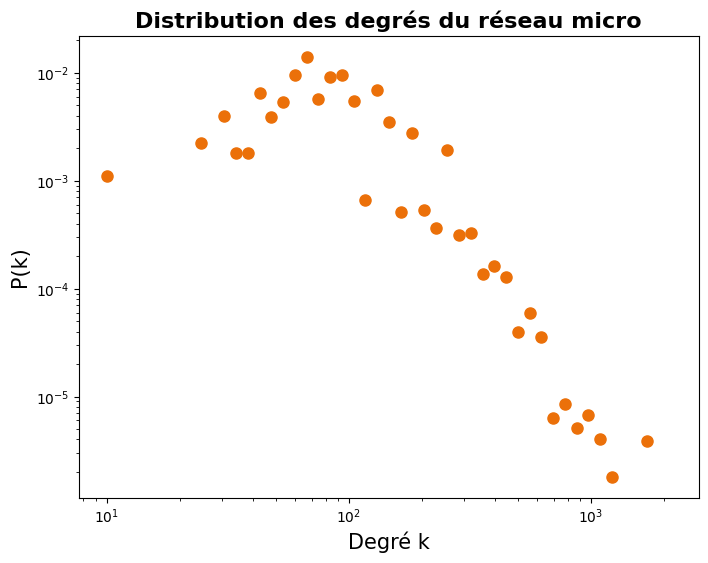

In [ ]:
#  Réseau micro : distribution des degrés

degree_distribution(G_macro, titre='Distribution des degrés du réseau micro')

La loi puissance ne semble vérifiée que pour k>100 (hyp: présence de gros hubs mais peu de lieux avec très peu de connections?)
Question: est-ce que cela vaut la peine de creuser ou l'étude du micro-réseau et du macro-réseau compléteront-elles directement ce premier graphique (présence ou non d'une loi puissance dans l'un ou l'autre de ces sous-réseaux)

### Degree mixing
Objectif: répondre à la question qui se connecte avec qui?

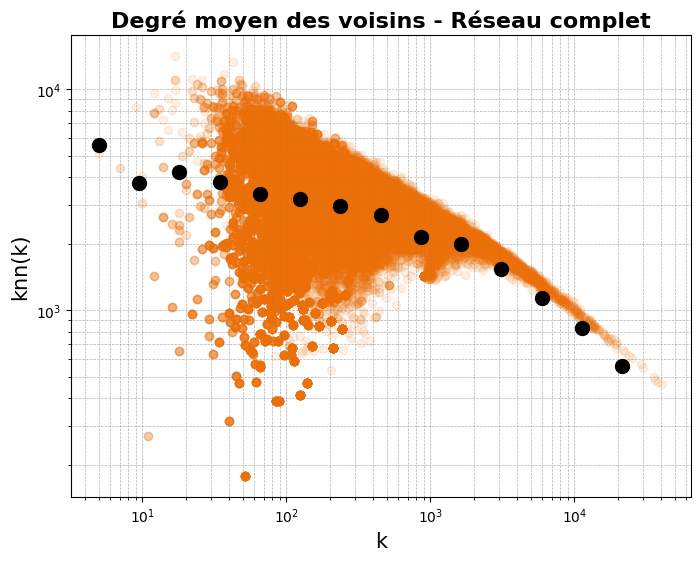

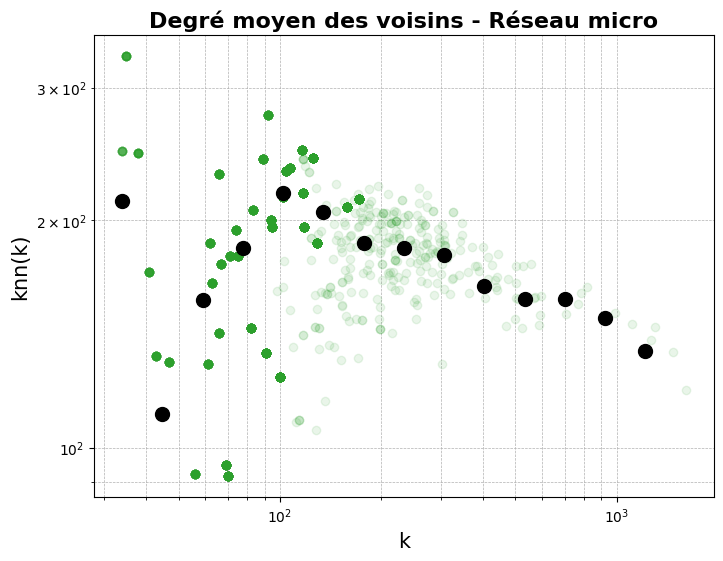

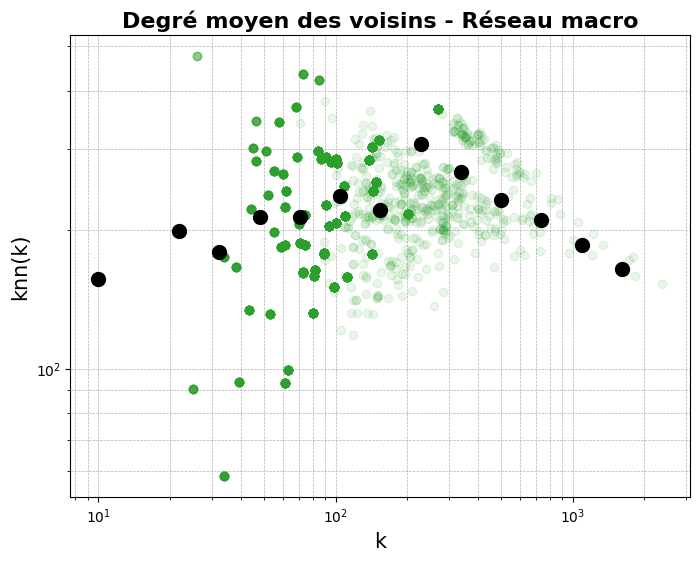

In [ ]:
# Pour le réseau complet
plot_knn_logbins(G_complet, titre='Degré moyen des voisins - Réseau complet')

# Pour le réseau micro
plot_knn_logbins(G_micro, titre='Degré moyen des voisins - Réseau micro')

# Pour le réseau macro
plot_knn_logbins(G_macro, titre='Degré moyen des voisins - Réseau macro')

Il semblerait que tous les établissements soient connectés à des hubs.

### La propriété rich-club

La courbe est croissante sur la partie droite : plus un lieu est populaire, plus il a de chances d'être connecté à un autre lieu populaire (n'est-ce pas un simple effet mathématique du à l'augmentation du nombre de connexions?) Les lieux peu connectés semblent isolés, ce qui pourrait indiquer avec le graphique précédent qu'ils sont connectés à des hubs mais ne se connectent pas entre eux. A partir d'un certain seuil de popularité tous les lieux semblent connectés entre eux.

Pour s'assurer que l'hyperconnectivité des lieux les plus connectés n'est pas du à un simple effet mathématique, il faudrait comparer cette courbe à un réseau aléatoire.



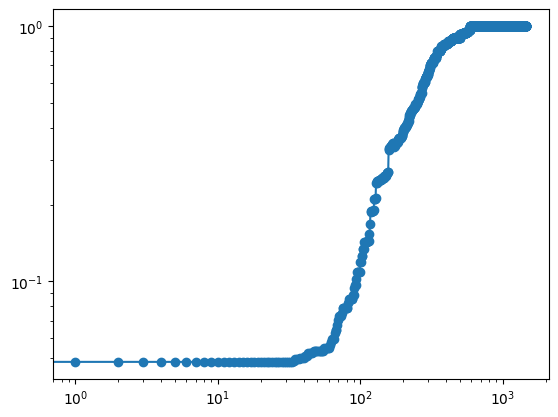

In [31]:
rc = nx.rich_club_coefficient(G_micro, normalized=False, seed=42)
plt.loglog(rc.keys(),rc.values(),'o-')

Comparaison avec un réseau aléatoire

L'IA conseillait de créer un réseau random avec nswap (en commentaire), j'ai préféré un réseau BA comme vu en cours qui crée naturellement des hubs. Le choix est dicutable comme nous n'avons pas de loi puissance, mais c'est une façon de se fixer les idées en première approche avec une interprétation simple du réseau random créé.

On observe une synergie entre les lieux qui ont entre 100 et 200 connections notamment : les utilisateurs ont tendance à naviguer entre ces lieux. La courbe redescend ensuite (et passe même en-dessous de la ligne représentant le modèle random(modèle BA dans ce cas)) : interprétation possible : les super_hubs sont connectés avec tout le monde.

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_19883/2730399516.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_{real} / \phi_{rand}$')


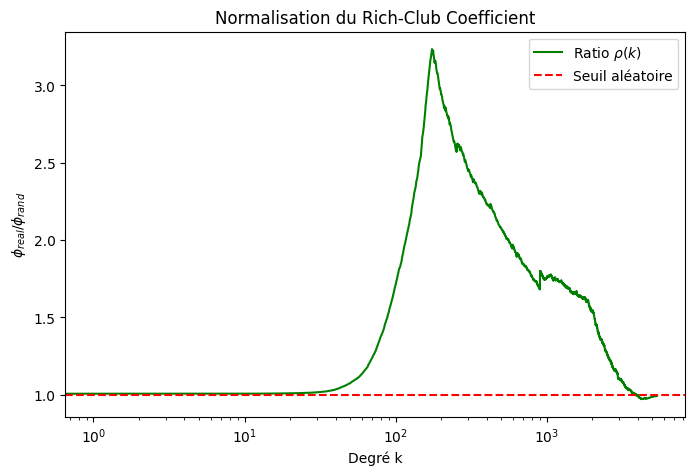

In [55]:


#  Création une version aléatoire de votre graphe G
# nswap définit le nombre de mélanges (plus il est haut, plus c'est aléatoire)
#G_random = nx.random_reference(G, nswap=G.number_of_edges() * 2, seed=42)

# Calculer le rich-club pour les deux
rc_real = nx.rich_club_coefficient(G, normalized=False)
#rc_rand = nx.rich_club_coefficient(G_random, normalized=False)

# N : nombre de nœuds de votre graphe réel
# m : nombre d'arêtes à attacher pour chaque nouveau nœud
# (On estime m par : nombre_total_aretes / nombre_total_noeuds)
N = G.number_of_nodes()
m = int(G.number_of_edges() / N)

G_ba = nx.barabasi_albert_graph(N, m)

# Calcul du rich-club pour comparer
rc_ba = nx.rich_club_coefficient(G_ba, normalized=False)

# Calculer le ratio de normalisation (rho)
# On s'assure de ne comparer que les degrés présents dans les deux
common_k = sorted(set(rc_real.keys()) & set(rc_ba.keys()))
rho = [rc_real[k] / rc_ba[k] for k in common_k]

#  Tracer le résultat
plt.figure(figsize=(8, 5))
plt.plot(common_k, rho, 'g-', label="Ratio $\\rho(k)$")
plt.axhline(y=1, color='r', linestyle='--', label="Seuil aléatoire")
plt.xscale('log')
plt.xlabel('Degré k')
plt.ylabel('$\phi_{real} / \phi_{rand}$')
plt.title('Normalisation du Rich-Club Coefficient')
plt.legend()
plt.show()

In [1]:
# Moyenne globale
clust_glob_complet = nx.average_clustering(G_complet)
clust_glob_faible = nx.average_clustering(G_micro)
clust_glob_fort = nx.average_clustering(G_macro)

print("Clustering global :")
print(f"Complet : {clust_glob_complet:.3f}")
print(f"Faible followers : {clust_glob_faible:.3f}")
print(f"Fort followers : {clust_glob_fort:.3f}")

NameError: name 'nx' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Histogrammes comparatifs
plt.figure(figsize=(8,6))
plt.hist(list(clustering_complet.values()), bins=20, alpha=0.5, label='Complet', color='#0D1B2A')
plt.hist(list(clustering_faible.values()), bins=20, alpha=0.5, label='≤100 followers', color='#1B263B')
plt.hist(list(clustering_fort.values()), bins=20, alpha=0.5, label='≥2500 followers', color='#162447')
plt.xlabel("Clustering local")
plt.ylabel("Nombre de nœuds")
plt.title("Distribution du clustering local")
plt.legend()
plt.show()

In [ ]:
import networkx as nx

def composants_connexes_info(G):
    """
    Calcule le nombre et la taille des composantes connexes d'un réseau.
    
    Paramètre :
    -----------
    G : networkx.Graph
    
    Retour :
    --------
    dict contenant :
        - nb_composantes : nombre de composantes
        - taille_composantes : liste des tailles
        - composante_max : taille de la plus grande composante
        - proportion_max : proportion de nœuds dans la plus grande composante
    """
    # Liste des composantes
    composantes = list(nx.connected_components(G))
    
    # Nombre de composantes
    nb_composantes = len(composantes)
    
    # Taille de chaque composante
    taille_composantes = [len(c) for c in composantes]
    
    # Taille de la plus grande composante
    composante_max = max(taille_composantes)
    
    # Proportion de nœuds dans la plus grande composante
    proportion_max = composante_max / G.number_of_nodes()
    
    return {
        "nb_composantes": nb_composantes,
        "taille_composantes": taille_composantes,
        "composante_max": composante_max,
        "proportion_max": proportion_max
    }

In [ ]:
info_complet = composants_connexes_info(G_complet)
info_faible  = composants_connexes_info(G_faible)
info_fort    = composants_connexes_info(G_fort)

print("=== Réseau complet ===")
print(info_complet)
print("=== Réseau faible followers (≤100) ===")
print(info_faible)
print("=== Réseau fort followers (≥2500) ===")
print(info_fort)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(info_complet["taille_composantes"], bins=20, alpha=0.5, label="Complet", color="#0D1B2A")
plt.hist(info_faible["taille_composantes"], bins=20, alpha=0.5, label="≤100 followers", color="#1B263B")
plt.hist(info_fort["taille_composantes"], bins=20, alpha=0.5, label="≥2500 followers", color="#162447")
plt.xlabel("Taille de composante")
plt.ylabel("Nombre de composantes")
plt.title("Distribution des tailles de composantes")
plt.legend()
plt.show()

In [ ]:
pip install python-louvain

In [ ]:
import networkx as nx
import community as community_louvain  # Louvain pour détection de communautés

def calcul_modularite(G):
    # Détection des communautés
    partition = community_louvain.best_partition(G)
    # partition : dict {noeud: numéro_communauté}
    
    # Calcul modularité
    Q = community_louvain.modularity(partition, G)
    return Q, partition

# Application aux trois réseaux
Q_complet, part_complet = calcul_modularite(G_complet)
Q_faible, part_faible   = calcul_modularite(G_micro)
Q_fort, part_fort       = calcul_modularite(G_macro)

print("Modularité :")
print(f"Réseau complet : {Q_complet:.3f}")
print(f"Faible followers : {Q_faible:.3f}")
print(f"Fort followers : {Q_fort:.3f}")

Clustering coefficient	Moyenne du clustering local	Tendance des établissements à former des triangles
Composantes connexes	Nb et taille des composantes	Cohésion du réseau
Degré assortatif	Corrélation degrés voisins	Réseaux où nœuds très connectés se connectent à d’autres nœuds très connectés ?

Distance moyenne / diamètre	Chemin moyen et plus long chemin	Accessibilité du réseau et “petit monde”
Centralités (degré, proximité, intermédiarité)	Importance des nœuds	Identifier les établissements centraux dans chaque réseau